In [1]:

!pip install -q pyclipper shapely


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 29.2 MB/s eta 0:00:00


In [2]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import random
import string

# ============== DETERMINISTIC SEED ==============
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"✓ Random seed set to {SEED} (fully deterministic)")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

IMG_HEIGHT = 32
IMG_WIDTH = 128


✓ Random seed set to 42 (fully deterministic)
Device: cuda


In [4]:

DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/train-ocr-model')
MULTI_IMAGE_DIR = DATA_DIR / 'multiple_image_data'

json_path = MULTI_IMAGE_DIR / 'multiple_image.json'

with open(json_path, 'r') as f:
    all_annotations = json.load(f)

print(f"{'='*60}")
print(f"LOADING & CROPPING ALL WORDS")
print(f"{'='*60}")
print(f"  JSON: {json_path.name}")
print(f"  Annotation entries: {len(all_annotations)}")


def order_points(pts):
    """Order points: top-left, top-right, bottom-right, bottom-left."""
    rect = np.zeros((4, 2), dtype=np.float32)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect


def crop_and_warp(image, polygon, padding=2):
    """Crop text region using perspective transform."""
    if len(polygon) != 4:
        rect = cv2.minAreaRect(polygon.astype(np.float32))
        box = cv2.boxPoints(rect)
        polygon = box

    pts = order_points(polygon.astype(np.float32))

    width_top = np.linalg.norm(pts[1] - pts[0])
    width_bottom = np.linalg.norm(pts[2] - pts[3])
    width = int(max(width_top, width_bottom))

    height_left = np.linalg.norm(pts[3] - pts[0])
    height_right = np.linalg.norm(pts[2] - pts[1])
    height = int(max(height_left, height_right))

    if width < 5 or height < 5:
        return None

    dst = np.array([
        [0, 0], [width - 1, 0],
        [width - 1, height - 1], [0, height - 1]
    ], dtype=np.float32)

    M = cv2.getPerspectiveTransform(pts, dst)
    warped = cv2.warpPerspective(image, M, (width, height))

    if padding > 0:
        warped = cv2.copyMakeBorder(warped, padding, padding, padding, padding,
                                     cv2.BORDER_CONSTANT, value=(255, 255, 255))
    return warped


# Process ALL images
all_words = []  # List of {'image': cropped_rgb, 'text': str, 'source_image': str}

for entry_idx, entry in enumerate(all_annotations):
    image_filename = entry.get('file_upload', '')
    image_path = MULTI_IMAGE_DIR / image_filename

    if not image_path.exists():
        print(f"  ⚠ Image not found: {image_filename}")
        continue

    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = entry['annotations'][0]['result']
    orig_w = results[0]['original_width']
    orig_h = results[0]['original_height']

    # Parse polygons and texts
    poly_results = {}
    text_results = {}

    for r in results:
        rid = r['id']
        if r['type'] == 'polygon':
            points_pct = r['value']['points']
            pixel_points = []
            for px, py in points_pct:
                pixel_points.append([px * orig_w / 100.0, py * orig_h / 100.0])
            poly_results[rid] = np.array(pixel_points, dtype=np.float32)
        elif r['type'] == 'textarea':
            text_results[rid] = r['value']['text'][0] if r['value']['text'] else ''

    # Crop each word
    img_count = 0
    img_skipped = 0

    for rid, poly in poly_results.items():
        text = text_results.get(rid, '').strip()

        # Skip empty, very long, or control characters
        if not text or len(text) > 30:
            img_skipped += 1
            continue

        cropped = crop_and_warp(img, poly)
        if cropped is None or cropped.shape[0] < 8 or cropped.shape[1] < 8:
            img_skipped += 1
            continue

        all_words.append({
            'image': cropped,
            'text': text,
            'source_image': image_filename,
            'source_idx': entry_idx,
        })
        img_count += 1

    print(f"  Image [{entry_idx}]: {image_filename[:40]}... "
          f"→ {img_count} words cropped, {img_skipped} skipped")

print(f"\n  ✓ Total cropped words: {len(all_words)}")

# Stats
text_lengths = [len(w['text']) for w in all_words]
print(f"  Word lengths: min={min(text_lengths)}, max={max(text_lengths)}, "
      f"avg={np.mean(text_lengths):.1f}")

all_chars = set(''.join(w['text'] for w in all_words))
print(f"  Unique characters: {len(all_chars)}")

LOADING & CROPPING ALL WORDS
  JSON: multiple_image.json
  Annotation entries: 5
  Image [0]: 2a9f6148-Screenshot_2026-02-12_at_4.38.4... → 70 words cropped, 10 skipped
  Image [1]: bd7826d8-Screenshot_2026-02-12_at_5.42.2... → 70 words cropped, 10 skipped
  Image [2]: 98b6cb49-Screenshot_2026-02-12_at_6.51.3... → 70 words cropped, 10 skipped
  Image [3]: 8f0859a0-Screenshot_2026-02-12_at_8.16.2... → 70 words cropped, 10 skipped
  Image [4]: 0125a3c3-Screenshot_2026-02-12_at_8.46.5... → 70 words cropped, 10 skipped

  ✓ Total cropped words: 350
  Word lengths: min=1, max=26, avg=5.9
  Unique characters: 60


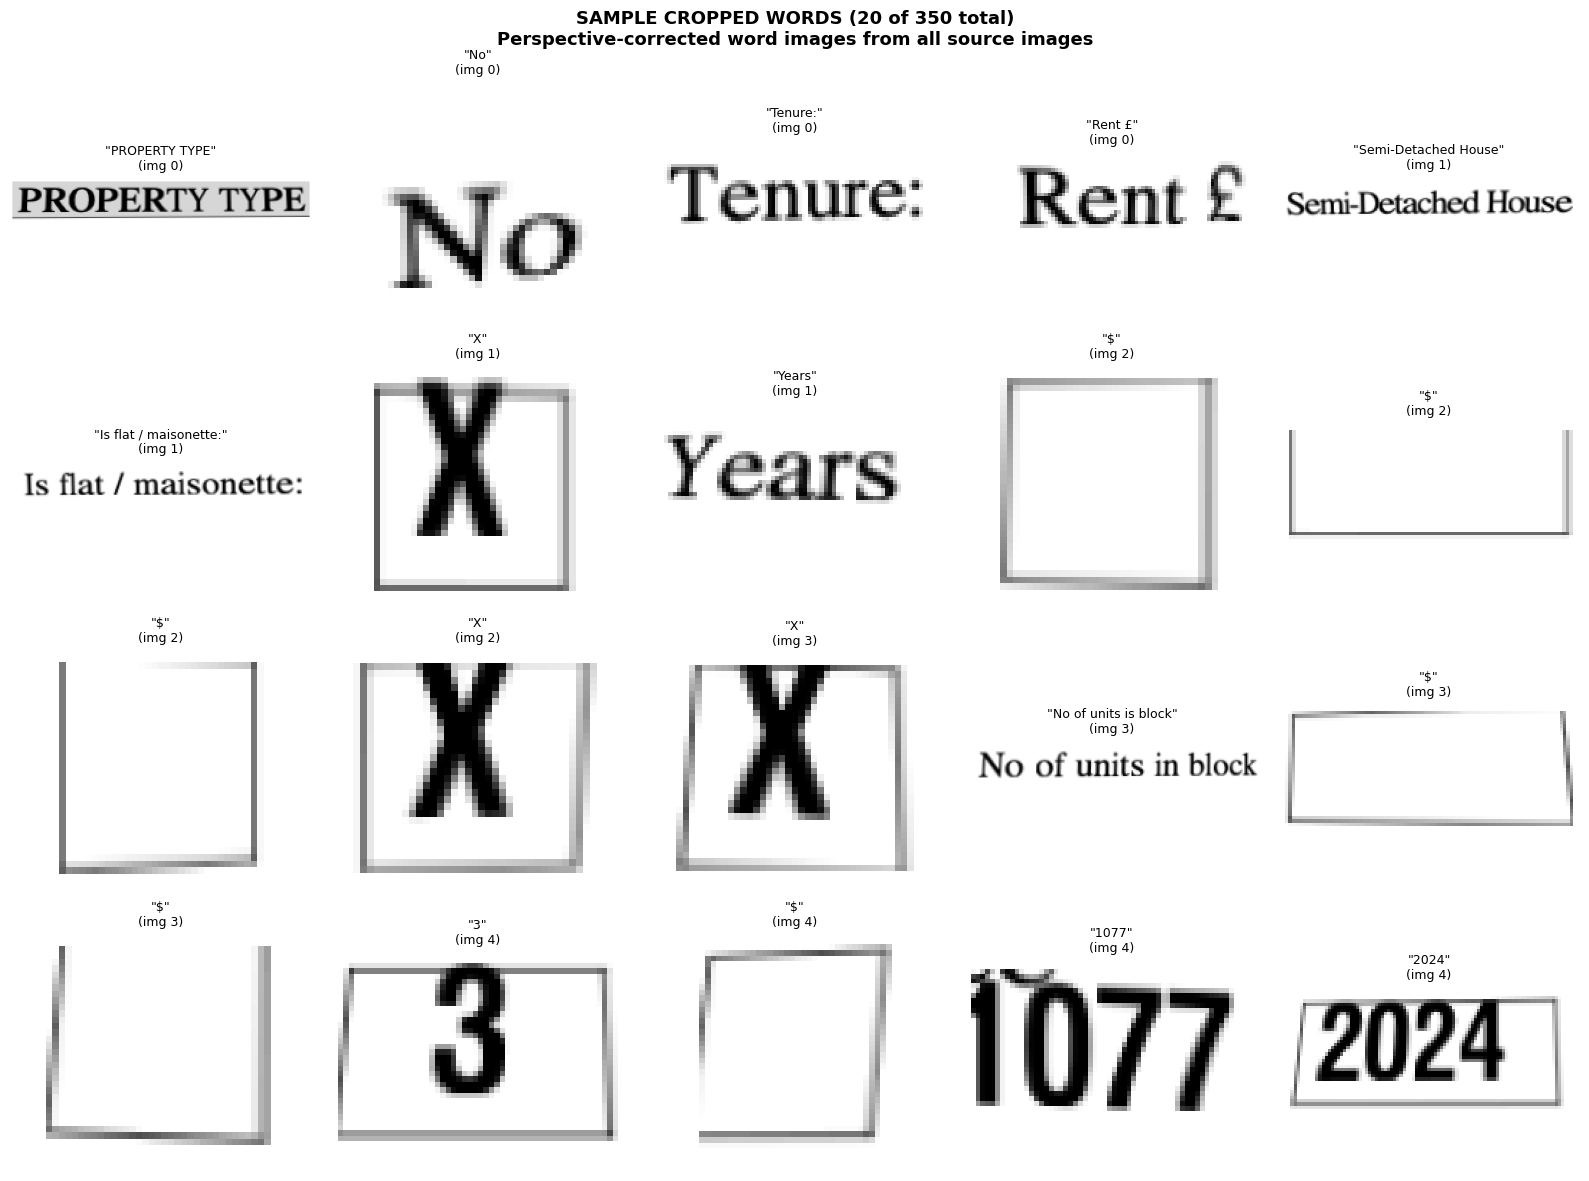

In [5]:

n_show = min(20, len(all_words))
cols = 5
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
axes = axes.flatten()

# Pick evenly spaced samples
indices = np.linspace(0, len(all_words) - 1, n_show, dtype=int)

for i, idx in enumerate(indices):
    word = all_words[idx]
    axes[i].imshow(word['image'])
    axes[i].set_title(f'"{word["text"]}"\n(img {word["source_idx"]})', fontsize=9)
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.suptitle(f'SAMPLE CROPPED WORDS ({n_show} of {len(all_words)} total)\n'
             f'Perspective-corrected word images from all source images',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:

class CharacterSet:
    """Character set for text recognition."""

    def __init__(self):
        self.characters = string.digits + string.ascii_lowercase + string.ascii_uppercase
        self.characters += "!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~ £"

        self.blank_token = '-'
        self.char_to_idx = {self.blank_token: 0}
        self.idx_to_char = {0: self.blank_token}

        for i, char in enumerate(self.characters):
            self.char_to_idx[char] = i + 1
            self.idx_to_char[i + 1] = char

        self.num_classes = len(self.characters) + 1

    def encode(self, text):
        return [self.char_to_idx.get(c, 0) for c in text]

    def decode(self, indices, remove_duplicates=True):
        chars = []
        prev_idx = None
        for idx in indices:
            if idx == 0:
                prev_idx = idx
                continue
            if remove_duplicates and idx == prev_idx:
                continue
            chars.append(self.idx_to_char.get(idx, ''))
            prev_idx = idx
        return ''.join(chars)


charset = CharacterSet()
print(f"✓ Character set: {charset.num_classes} classes")


class WordRecognitionDataset(Dataset):
    """Dataset of cropped word images for CRNN training."""

    def __init__(self, word_list, charset, img_height=32, img_width=128):
        self.words = word_list
        self.charset = charset
        self.img_height = img_height
        self.img_width = img_width

    def __len__(self):
        return len(self.words)

    def __getitem__(self, idx):
        word = self.words[idx]
        img = word['image']
        text = word['text']

        # Convert to grayscale
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # Resize preserving aspect ratio
        h, w = img.shape
        ratio = self.img_height / h
        new_w = min(int(w * ratio), self.img_width)
        new_w = max(new_w, 1)

        img = cv2.resize(img, (new_w, self.img_height))

        # Pad to fixed width
        if new_w < self.img_width:
            img = np.pad(img, ((0, 0), (0, self.img_width - new_w)),
                        mode='constant', constant_values=0)

        # Normalize to [-1, 1]
        img = img.astype(np.float32) / 255.0
        img = (img - 0.5) / 0.5

        img_tensor = torch.from_numpy(img).unsqueeze(0)  # (1, H, W)
        encoded = torch.tensor(self.charset.encode(text), dtype=torch.long)

        return {
            'image': img_tensor,
            'text': text,
            'encoded': encoded,
            'length': len(text),
        }


dataset = WordRecognitionDataset(all_words, charset, IMG_HEIGHT, IMG_WIDTH)
print(f"✓ Dataset: {len(dataset)} samples")

# Verify
sample = dataset[0]
print(f"  Image tensor: {sample['image'].shape}")
print(f"  Text: \"{sample['text']}\"")
print(f"  Encoded: {sample['encoded'].tolist()}")

✓ Character set: 97 classes
✓ Dataset: 350 samples
  Image tensor: torch.Size([1, 32, 128])
  Text: "PROPERTY TYPE"
  Encoded: [52, 54, 51, 52, 41, 54, 56, 61, 95, 56, 61, 52, 41]


In [8]:

def collate_fn(batch):
    """Custom collate for variable-length text."""
    images = torch.stack([item['image'] for item in batch])
    texts = [item['text'] for item in batch]

    max_len = max(len(item['encoded']) for item in batch)
    encoded = torch.zeros(len(batch), max_len, dtype=torch.long)
    lengths = torch.zeros(len(batch), dtype=torch.long)

    for i, item in enumerate(batch):
        enc = item['encoded']
        encoded[i, :len(enc)] = enc
        lengths[i] = item['length']

    return {'images': images, 'texts': texts, 'encoded': encoded, 'lengths': lengths}


BATCH_SIZE = 32
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn)

# Verify
for batch in train_loader:
    print(f"✓ DataLoader ready!")
    print(f"  Batch images: {batch['images'].shape}")
    print(f"  Batch texts: {batch['texts'][:3]}...")
    print(f"  Batch encoded: {batch['encoded'].shape}")
    print(f"  Batch lengths: {batch['lengths'][:5]}")
    print(f"  Total batches: {len(train_loader)}")
    break


✓ DataLoader ready!
  Batch images: torch.Size([32, 1, 32, 128])
  Batch texts: ['$', 'PROPERTY TYPE', '12']...
  Batch encoded: torch.Size([32, 26])
  Batch lengths: tensor([ 1, 13,  2,  8,  1])
  Total batches: 11


In [9]:

class CRNN(nn.Module):
    """CRNN: CNN + BiLSTM + CTC for text recognition."""

    def __init__(self, num_classes, img_height=32, hidden_size=256):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(), nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(512, 512, 2), nn.BatchNorm2d(512), nn.ReLU()
        )

        self.rnn = nn.LSTM(512, hidden_size, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        conv = self.cnn(x)
        b, c, h, w = conv.size()
        conv = conv.squeeze(2).permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv)
        output = self.fc(rnn_out)
        return output


model = CRNN(num_classes=charset.num_classes).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✓ CRNN: {total_params:,} parameters, {charset.num_classes} classes")


✓ CRNN: 7,178,081 parameters, 97 classes


In [10]:

class CTCDecoder:
    """Greedy CTC decoder."""

    def __init__(self, charset):
        self.charset = charset

    def decode(self, preds):
        """Greedy decode batch of predictions."""
        _, max_indices = preds.max(dim=2)
        texts = []
        for indices in max_indices:
            text = self.charset.decode(indices.cpu().numpy())
            texts.append(text)
        return texts

    def encode(self, texts):
        """Encode texts for CTC loss."""
        batch_encoded = []
        lengths = []
        for text in texts:
            encoded = self.charset.encode(text)
            batch_encoded.extend(encoded)
            lengths.append(len(encoded))
        return (torch.tensor(batch_encoded, dtype=torch.long),
                torch.tensor(lengths, dtype=torch.long))


criterion = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
decoder = CTCDecoder(charset)
print("✓ CTC Loss + Decoder ready!")

✓ CTC Loss + Decoder ready!


In [11]:

torch.manual_seed(SEED)
model = CRNN(num_classes=charset.num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

NUM_EPOCHS = 50

epoch_losses = []
epoch_accuracies = []

print(f"{'='*60}")
print(f"TRAINING CRNN ON {len(dataset)} WORDS")
print(f"{'='*60}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Batches/epoch: {len(train_loader)}")
print(f"  Optimizer: Adam, lr=0.001, StepLR(15, 0.5)")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    n_batches = 0

    for batch in train_loader:
        images = batch['images'].to(device)
        texts = batch['texts']

        outputs = model(images)
        log_probs = F.log_softmax(outputs, dim=2).permute(1, 0, 2)

        targets, target_lengths = decoder.encode(texts)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)

        input_lengths = torch.full((images.size(0),), log_probs.size(0),
                                   dtype=torch.long).to(device)

        loss = criterion(log_probs, targets, input_lengths, target_lengths)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    scheduler.step()
    avg_loss = total_loss / n_batches
    epoch_losses.append(avg_loss)

    # Compute accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in train_loader:
            images = batch['images'].to(device)
            texts = batch['texts']
            outputs = model(images)
            preds = decoder.decode(outputs)
            for pred, gt in zip(preds, texts):
                if pred.lower() == gt.lower():
                    correct += 1
                total += 1

    acc = correct / total if total > 0 else 0
    epoch_accuracies.append(acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}: Loss={avg_loss:.4f} | "
              f"Accuracy={acc*100:.1f}% ({correct}/{total})")

print(f"\n{'='*60}")
print(f"  FINAL: Loss={epoch_losses[-1]:.4f} | Accuracy={epoch_accuracies[-1]*100:.1f}%")
print(f"{'='*60}")


TRAINING CRNN ON 350 WORDS
  Epochs: 50
  Batch size: 32
  Batches/epoch: 11
  Optimizer: Adam, lr=0.001, StepLR(15, 0.5)

  Epoch   1/50: Loss=15.8379 | Accuracy=0.0% (0/350)
  Epoch   5/50: Loss=2.3183 | Accuracy=10.3% (36/350)
  Epoch  10/50: Loss=1.4091 | Accuracy=43.1% (151/350)
  Epoch  15/50: Loss=0.9690 | Accuracy=51.4% (180/350)
  Epoch  20/50: Loss=0.7076 | Accuracy=55.1% (193/350)
  Epoch  25/50: Loss=0.5228 | Accuracy=56.3% (197/350)
  Epoch  30/50: Loss=0.3267 | Accuracy=64.0% (224/350)
  Epoch  35/50: Loss=0.2351 | Accuracy=71.4% (250/350)
  Epoch  40/50: Loss=0.1656 | Accuracy=81.7% (286/350)
  Epoch  45/50: Loss=0.1266 | Accuracy=85.4% (299/350)
  Epoch  50/50: Loss=0.0877 | Accuracy=96.3% (337/350)

  FINAL: Loss=0.0877 | Accuracy=96.3%


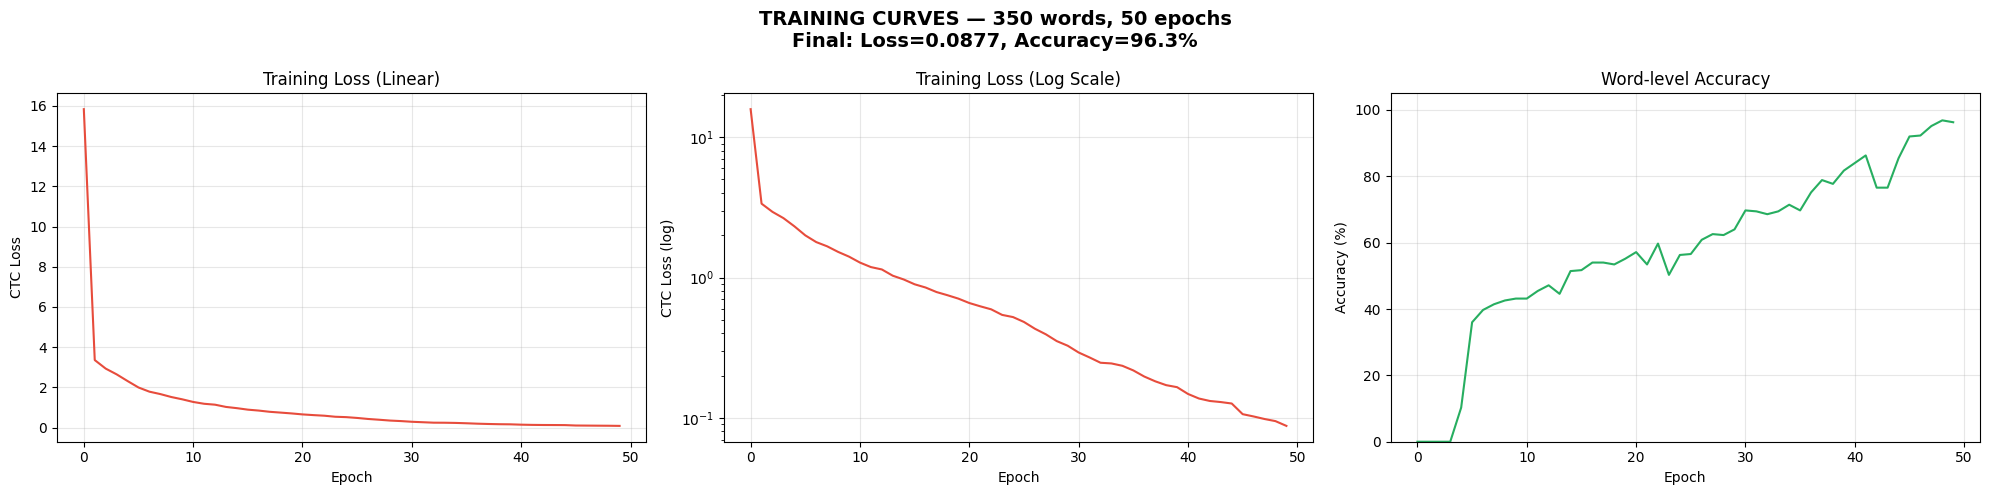

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loss (linear)
axes[0].plot(epoch_losses, color='#e74c3c', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CTC Loss')
axes[0].set_title('Training Loss (Linear)')
axes[0].grid(True, alpha=0.3)

# Loss (log)
axes[1].plot(epoch_losses, color='#e74c3c', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('CTC Loss (log)')
axes[1].set_title('Training Loss (Log Scale)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Accuracy
axes[2].plot([a * 100 for a in epoch_accuracies], color='#27ae60', linewidth=1.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_title('Word-level Accuracy')
axes[2].set_ylim(0, 105)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'TRAINING CURVES — {len(dataset)} words, {NUM_EPOCHS} epochs\n'
             f'Final: Loss={epoch_losses[-1]:.4f}, Accuracy={epoch_accuracies[-1]*100:.1f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


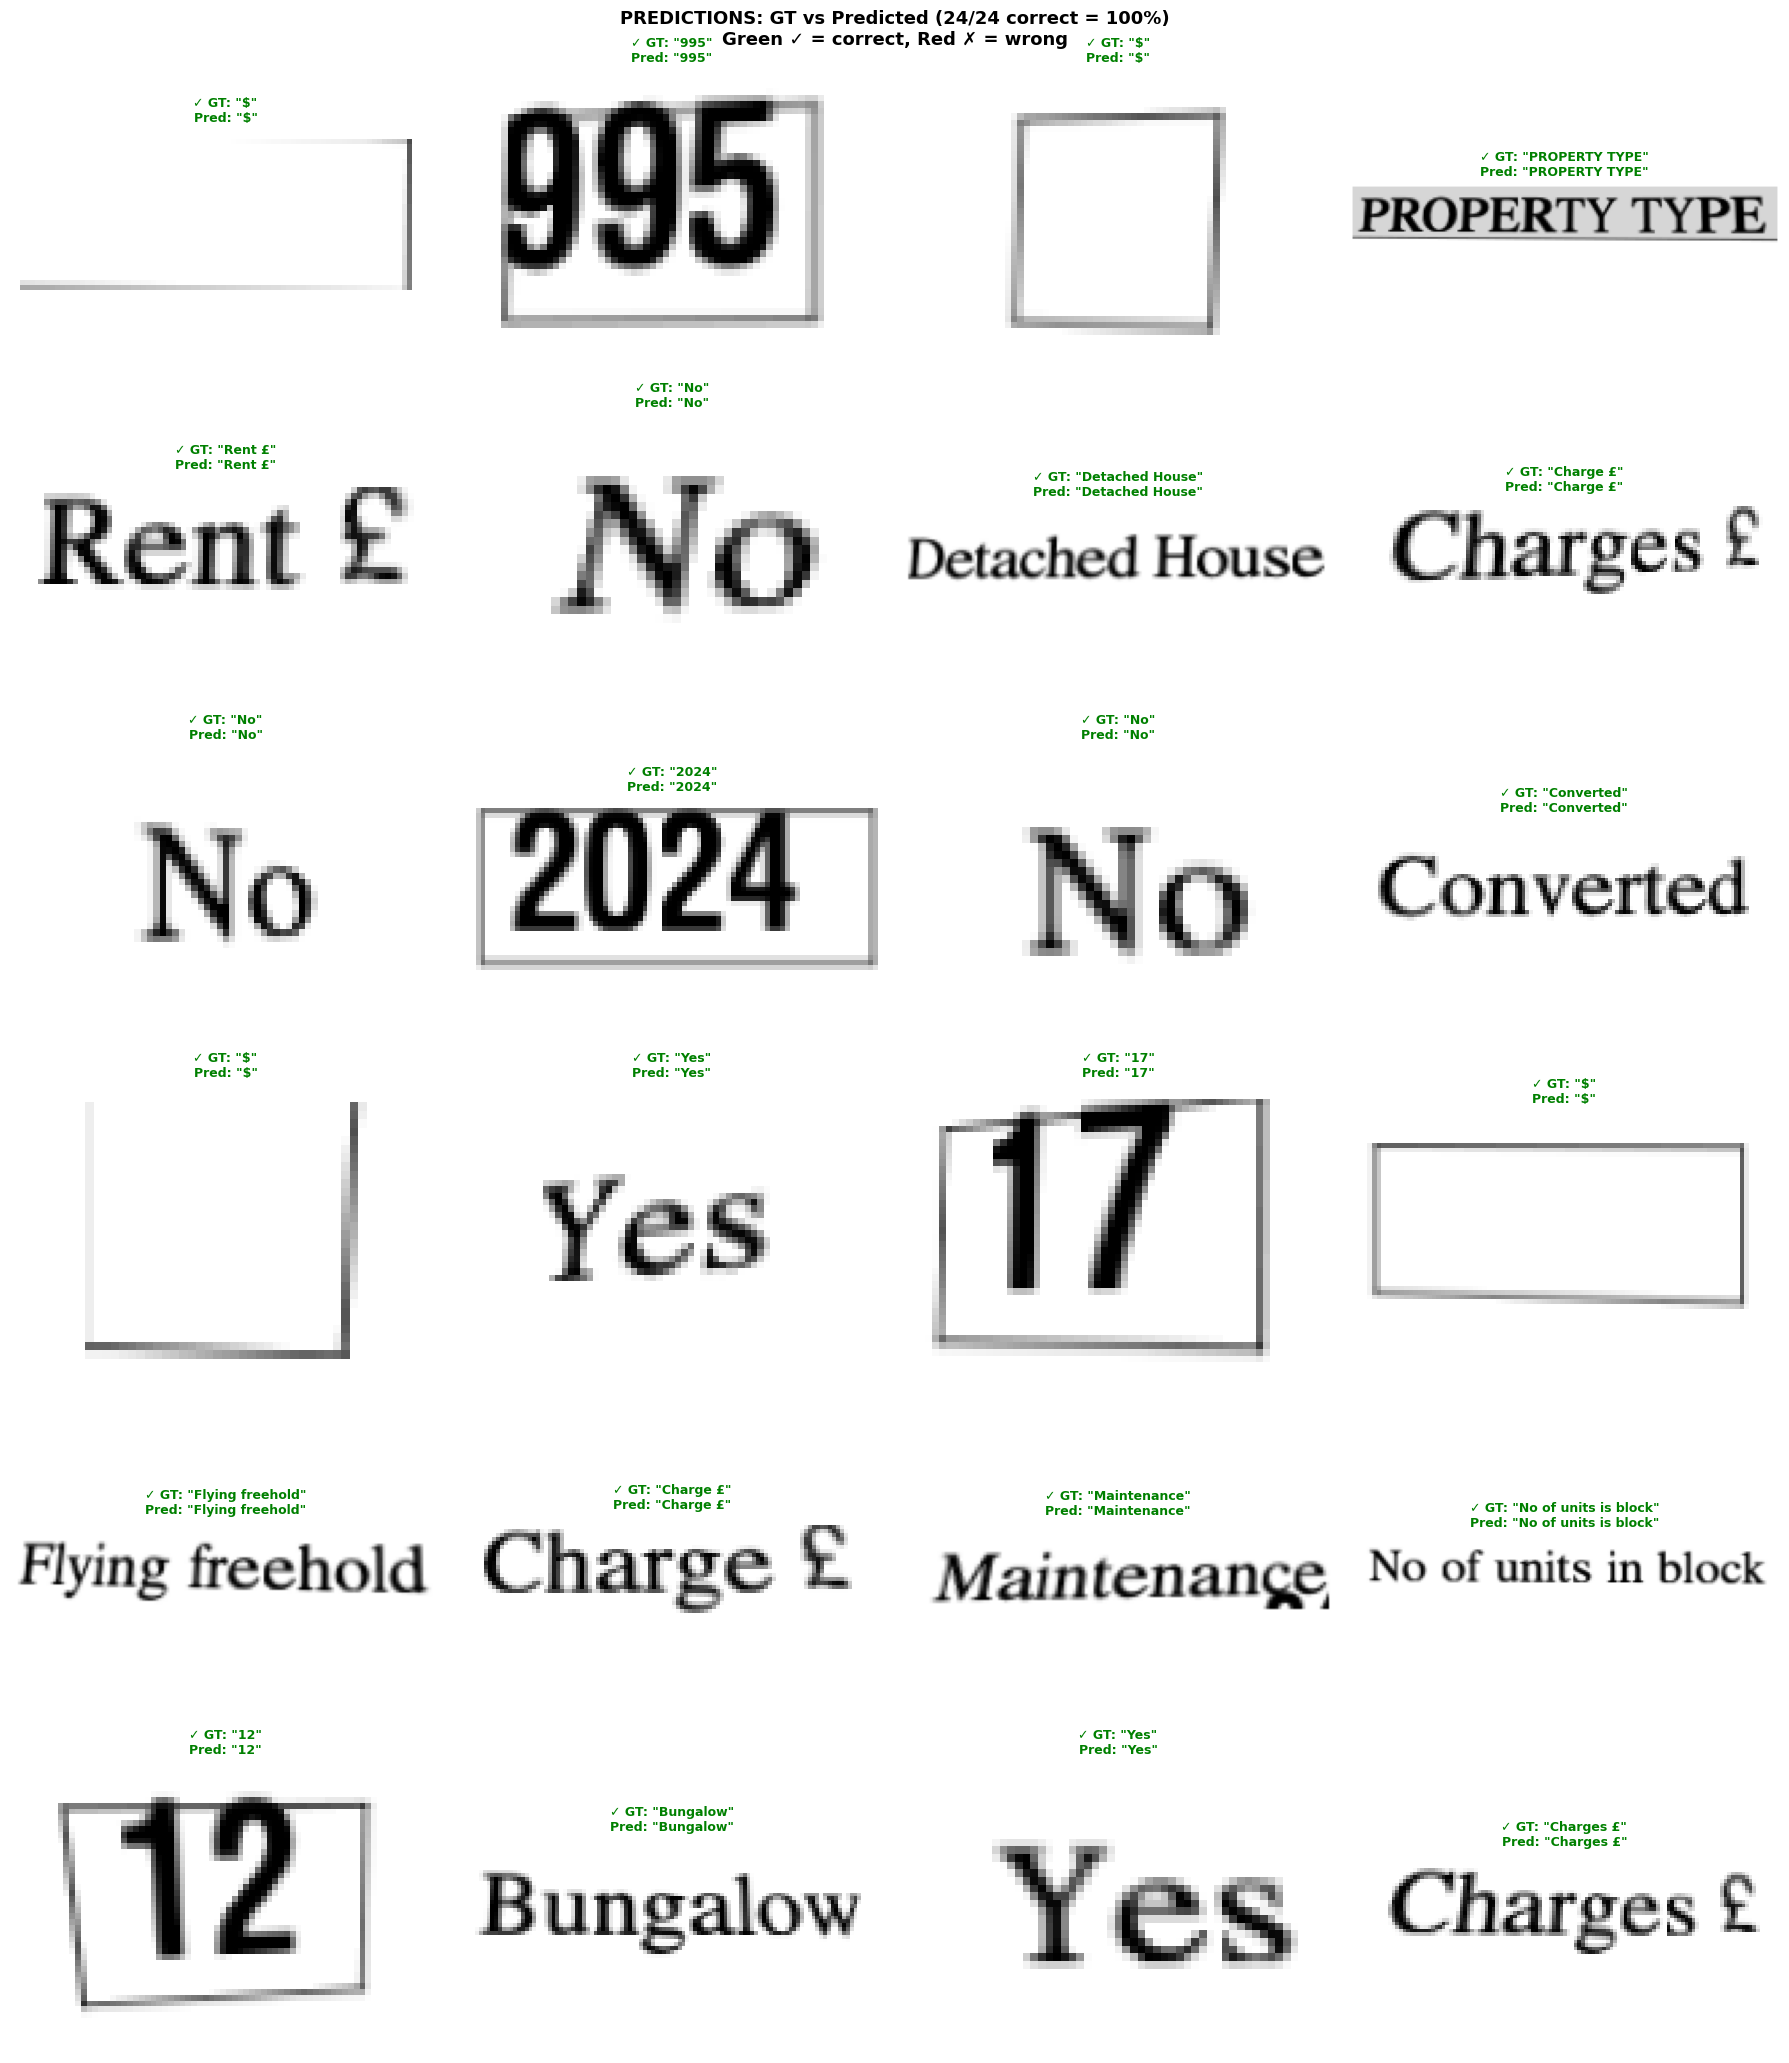

In [13]:

n_show = min(24, len(dataset))
cols = 4
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 3.5 * rows))
axes = axes.flatten()

# Pick random samples
random.seed(SEED)
show_indices = random.sample(range(len(dataset)), n_show)

model.eval()
correct_count = 0

for i, idx in enumerate(show_indices):
    sample = dataset[idx]
    img_tensor = sample['image'].unsqueeze(0).to(device)
    gt_text = sample['text']

    with torch.no_grad():
        output = model(img_tensor)
        pred_text = decoder.decode(output)[0]

    match = pred_text.lower() == gt_text.lower()
    if match:
        correct_count += 1

    # Show the cropped word image (original RGB)
    word_img = all_words[idx]['image']
    axes[i].imshow(word_img)

    color = 'green' if match else 'red'
    symbol = '✓' if match else '✗'
    axes[i].set_title(f'{symbol} GT: "{gt_text}"\nPred: "{pred_text}"',
                      fontsize=9, color=color, fontweight='bold')
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].axis('off')

sample_acc = correct_count / n_show * 100
plt.suptitle(f'PREDICTIONS: GT vs Predicted ({correct_count}/{n_show} correct = {sample_acc:.0f}%)\n'
             f'Green ✓ = correct, Red ✗ = wrong',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:

print(f"{'='*60}")
print(f"PER-WORD ACCURACY BREAKDOWN")
print(f"{'='*60}")

model.eval()
correct_words = []
wrong_words = []

with torch.no_grad():
    for idx in range(len(dataset)):
        sample = dataset[idx]
        img_tensor = sample['image'].unsqueeze(0).to(device)
        gt_text = sample['text']

        output = model(img_tensor)
        pred_text = decoder.decode(output)[0]

        if pred_text.lower() == gt_text.lower():
            correct_words.append({'gt': gt_text, 'pred': pred_text, 'idx': idx})
        else:
            wrong_words.append({'gt': gt_text, 'pred': pred_text, 'idx': idx})

total_accuracy = len(correct_words) / len(dataset) * 100
print(f"\n  Overall: {len(correct_words)}/{len(dataset)} = {total_accuracy:.1f}%")
print(f"  Correct: {len(correct_words)}")
print(f"  Wrong:   {len(wrong_words)}")

# Show accuracy by word length
print(f"\n  Accuracy by word length:")
length_stats = {}
for idx in range(len(dataset)):
    text = dataset.words[idx]['text']
    l = len(text)
    bucket = f"{l}" if l <= 10 else "11+"
    if bucket not in length_stats:
        length_stats[bucket] = {'correct': 0, 'total': 0}
    length_stats[bucket]['total'] += 1

for w in correct_words:
    l = len(w['gt'])
    bucket = f"{l}" if l <= 10 else "11+"
    length_stats[bucket]['correct'] += 1

for bucket in sorted(length_stats.keys(), key=lambda x: int(x.replace('+', ''))):
    s = length_stats[bucket]
    acc = s['correct'] / s['total'] * 100 if s['total'] > 0 else 0
    bar = '█' * int(acc / 5) + '░' * (20 - int(acc / 5))
    print(f"    Length {bucket:>3s}: {bar} {acc:5.1f}% ({s['correct']}/{s['total']})")

# Show some wrong predictions
if wrong_words:
    print(f"\n  Sample WRONG predictions (up to 15):")
    for w in wrong_words[:15]:
        print(f"    GT: \"{w['gt']}\" → Pred: \"{w['pred']}\"")

# Visualize accuracy by source image
print(f"\n  Accuracy by source image:")
img_stats = {}
for idx in range(len(dataset)):
    src = all_words[idx]['source_idx']
    if src not in img_stats:
        img_stats[src] = {'correct': 0, 'total': 0,
                          'name': all_words[idx]['source_image'][:30]}
    img_stats[src]['total'] += 1

for w in correct_words:
    src = all_words[w['idx']]['source_idx']
    img_stats[src]['correct'] += 1

for src in sorted(img_stats.keys()):
    s = img_stats[src]
    acc = s['correct'] / s['total'] * 100
    print(f"    Image [{src}] {s['name']}... "
          f"→ {acc:.1f}% ({s['correct']}/{s['total']})")

PER-WORD ACCURACY BREAKDOWN

  Overall: 337/350 = 96.3%
  Correct: 337
  Wrong:   13

  Accuracy by word length:
    Length   1: ████████████████████ 100.0% (133/133)
    Length   2: ████████████████████ 100.0% (32/32)
    Length   3: ████████████████████ 100.0% (35/35)
    Length   4: ██████████████████░░  90.0% (18/20)
    Length   5: ████████████████████ 100.0% (5/5)
    Length   6: ████████████████████ 100.0% (10/10)
    Length   7: ████████████████████ 100.0% (6/6)
    Length   8: ████████████████████ 100.0% (15/15)
    Length   9: ████████████████████ 100.0% (14/14)
    Length  10: ████████████████████ 100.0% (5/5)
    Length 11+: █████████████████░░░  85.3% (64/75)

  Sample WRONG predictions (up to 15):
    GT: "Terraced House" → Pred: "Teraced House"
    GT: "2858" → Pred: "28"
    GT: "Terraced House" → Pred: "Teraced House"
    GT: "2534" → Pred: "254"
    GT: "No. of floors in block" → Pred: "No of flors in block"
    GT: "PROPERTY TYPE" → Pred: "PROPRTY TYPE"
    GT: "Terr

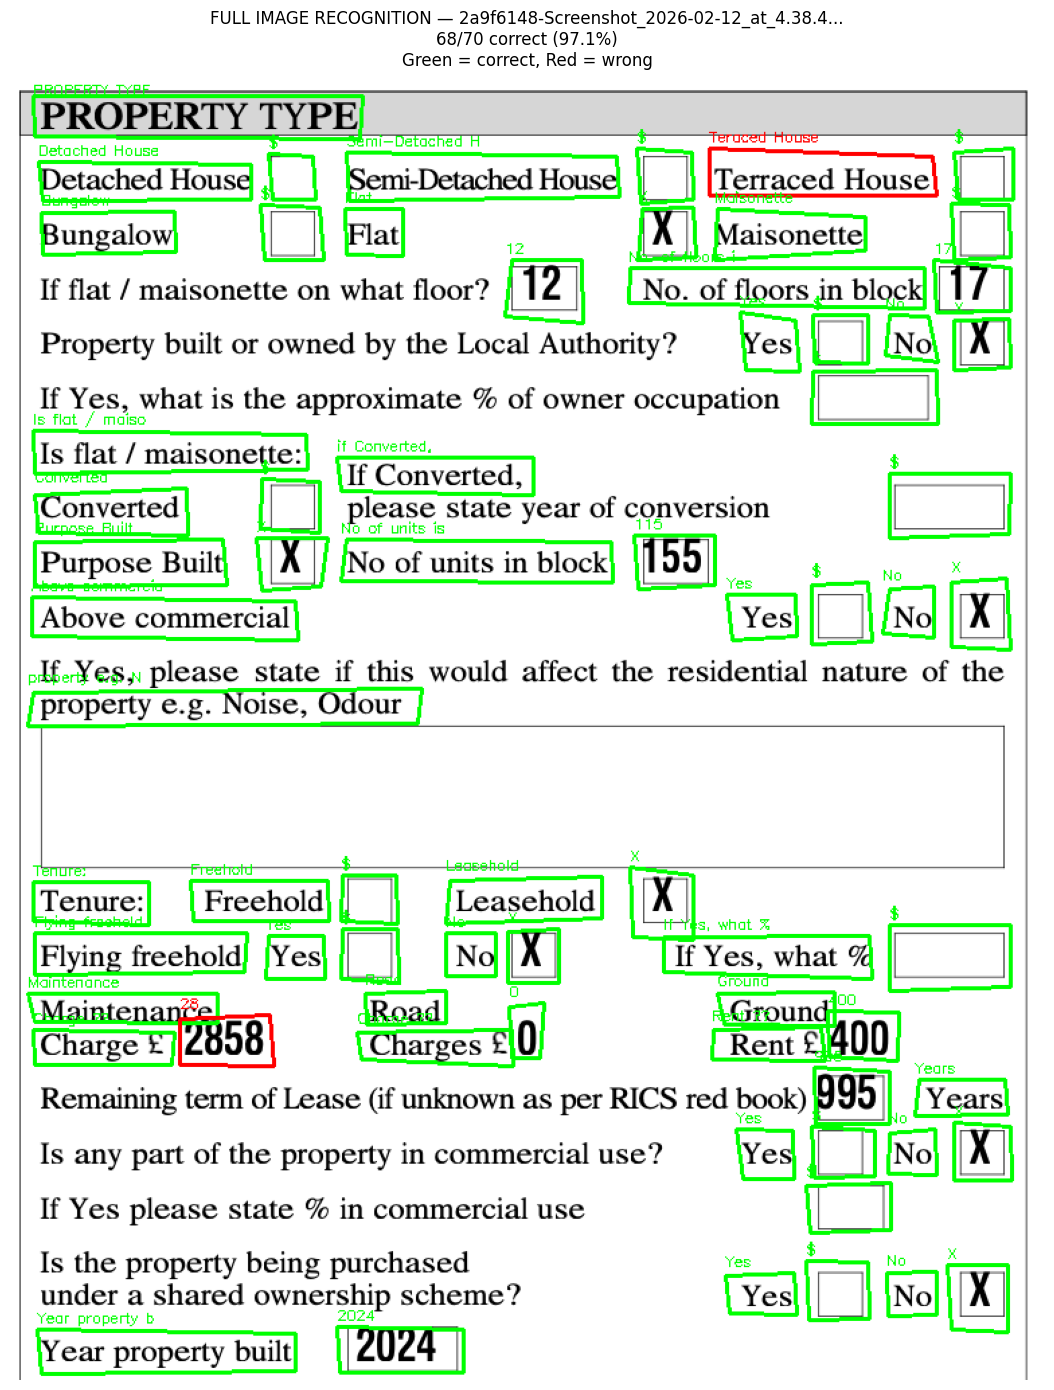


TRAINING SUMMARY
  Total words trained on: 350
  Source images: 5
  Final loss: 0.0877
  Final accuracy: 96.3%
  Total correct: 337/350


In [16]:

def recognize_word(model, image, polygon, charset, decoder, device,
                   img_height=32, img_width=128):
    """
    Crop a word region from an image using the polygon,
    then run CRNN recognition.
    """
    # Crop
    cropped = crop_and_warp(image, polygon)
    if cropped is None:
        return None, None

    # Preprocess
    if len(cropped.shape) == 3:
        gray = cv2.cvtColor(cropped, cv2.COLOR_RGB2GRAY)
    else:
        gray = cropped

    h, w = gray.shape
    ratio = img_height / h
    new_w = min(int(w * ratio), img_width)
    new_w = max(new_w, 1)
    resized = cv2.resize(gray, (new_w, img_height))

    if new_w < img_width:
        resized = np.pad(resized, ((0, 0), (0, img_width - new_w)),
                        mode='constant', constant_values=0)

    normalized = resized.astype(np.float32) / 255.0
    normalized = (normalized - 0.5) / 0.5

    img_tensor = torch.from_numpy(normalized).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        pred_text = decoder.decode(output)[0]

    return pred_text, cropped


# ————————————————————————————————————————————————————
# OPTION 1: Test all words from a specific training image
# ————————————————————————————————————————————————————
# This runs recognition on every word from the first image
# to demonstrate the full pipeline

test_entry = all_annotations[0]
test_filename = test_entry.get('file_upload', '')
test_img_path = MULTI_IMAGE_DIR / test_filename

test_img = cv2.imread(str(test_img_path))
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

test_results = test_entry['annotations'][0]['result']
test_orig_w = test_results[0]['original_width']
test_orig_h = test_results[0]['original_height']

test_polys = {}
test_texts = {}
for r in test_results:
    rid = r['id']
    if r['type'] == 'polygon':
        pts_pct = r['value']['points']
        px_pts = [[px * test_orig_w / 100.0, py * test_orig_h / 100.0]
                  for px, py in pts_pct]
        test_polys[rid] = np.array(px_pts, dtype=np.float32)
    elif r['type'] == 'textarea':
        test_texts[rid] = r['value']['text'][0] if r['value']['text'] else ''

# Visualize image with predicted text
vis_img = test_img.copy()
correct = 0
total = 0

for rid, poly in test_polys.items():
    gt_text = test_texts.get(rid, '').strip()
    if not gt_text or len(gt_text) > 30:
        continue

    pred_text, _ = recognize_word(model, test_img, poly, charset, decoder, device)
    if pred_text is None:
        continue

    total += 1
    match = pred_text.lower() == gt_text.lower()
    if match:
        correct += 1

    pts = poly.astype(np.int32)
    color = (0, 255, 0) if match else (255, 0, 0)
    cv2.polylines(vis_img, [pts], True, color, 2)

    # Put predicted text near polygon
    x, y = int(pts[:, 0].min()), int(pts[:, 1].min()) - 5
    cv2.putText(vis_img, pred_text[:15], (max(0, x), max(15, y)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)

fig, ax = plt.subplots(1, 1, figsize=(14, 14))
ax.imshow(vis_img)
ax.set_title(f'FULL IMAGE RECOGNITION — {test_filename[:40]}...\n'
             f'{correct}/{total} correct ({correct/total*100:.1f}%)\n'
             f'Green = correct, Red = wrong', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

# ————————————————————————————————————————————————————
# OPTION 2: Test with uploaded image (Colab)
# ————————————————————————————————————————————————————
# from google.colab import files
# uploaded = files.upload()
# for fname in uploaded:
#     nparr = np.frombuffer(uploaded[fname], np.uint8)
#     test_img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
#     test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
#     # You'll need polygon coordinates for the word regions
#     # Use your detection model (DBNet) to get them first!

print(f"\n{'='*60}")
print(f"TRAINING SUMMARY")
print(f"{'='*60}")
print(f"  Total words trained on: {len(dataset)}")
print(f"  Source images: {len(all_annotations)}")
print(f"  Final loss: {epoch_losses[-1]:.4f}")
print(f"  Final accuracy: {epoch_accuracies[-1]*100:.1f}%")
print(f"  Total correct: {len(correct_words)}/{len(dataset)}")
print(f"{'='*60}")


CNN FEATURE MAP VISUALIZATION
  Visualizing feature maps for: "PROPERTY TYPE"
  Input tensor: torch.Size([1, 1, 32, 128])



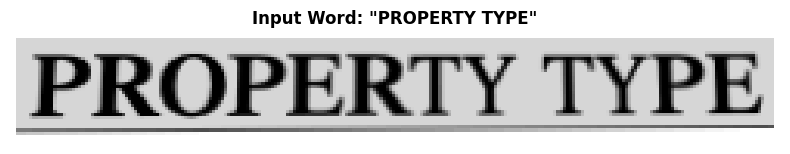

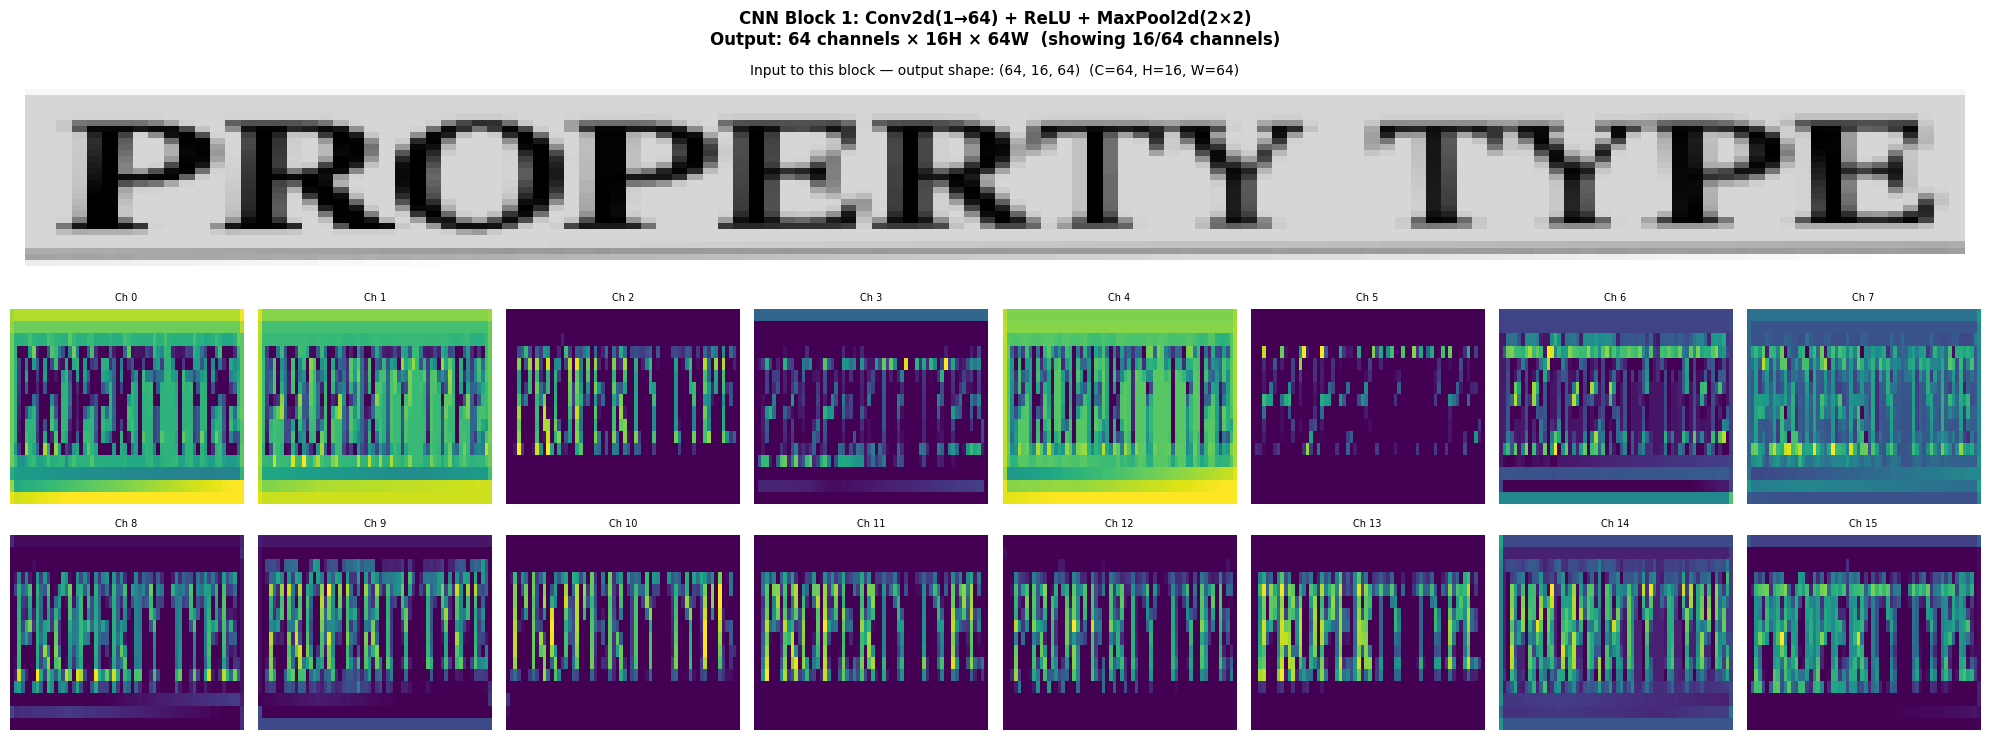

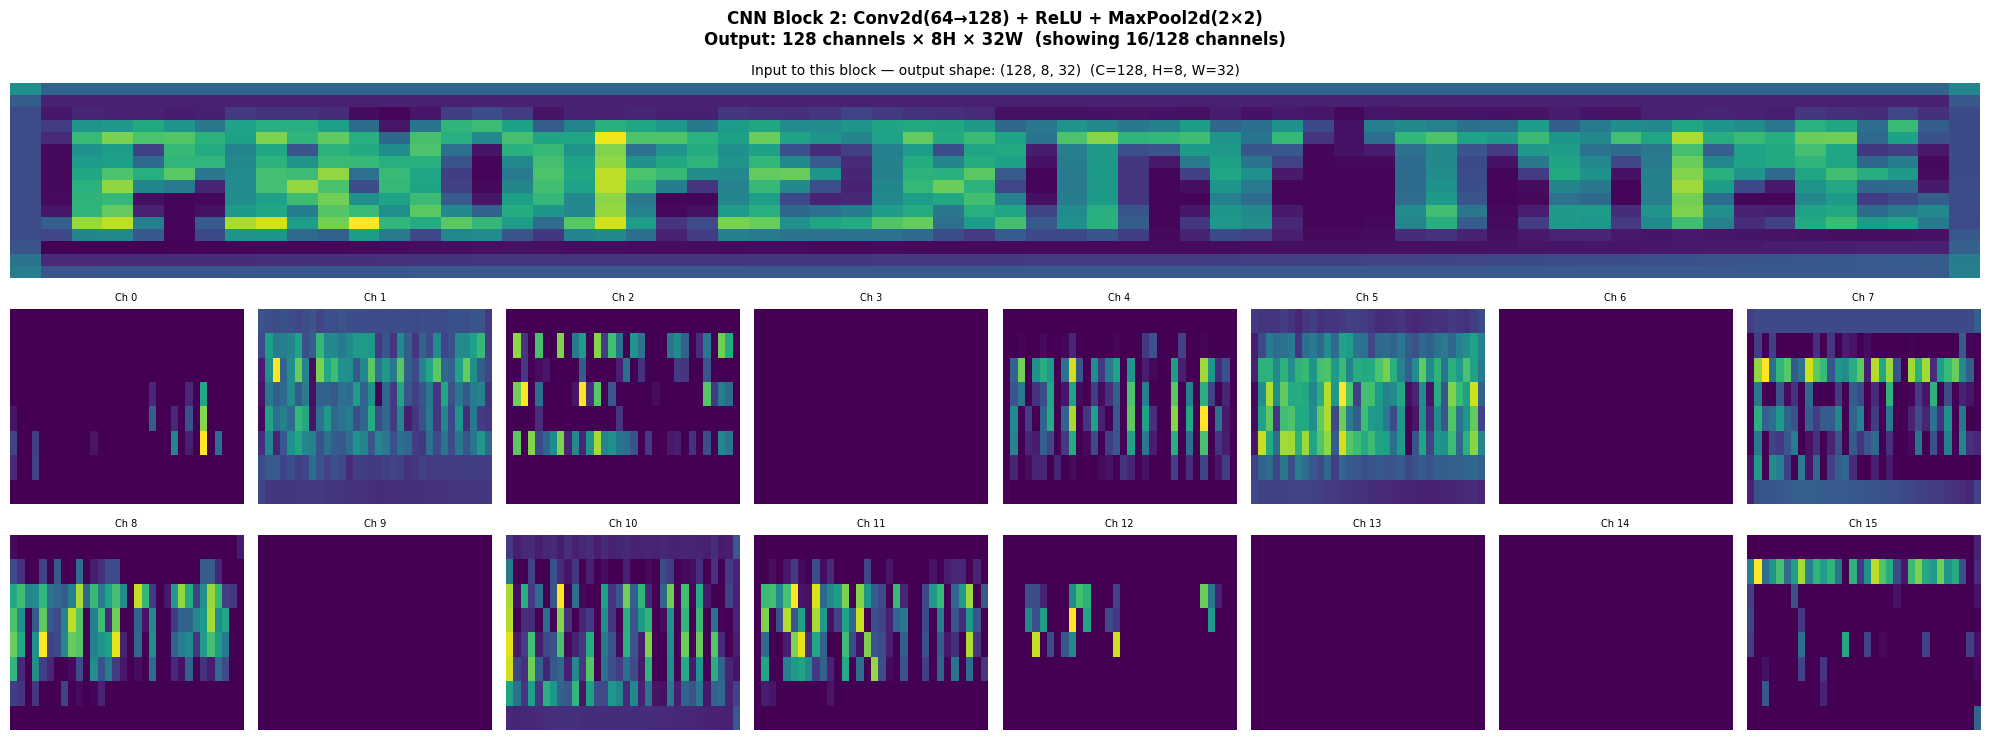

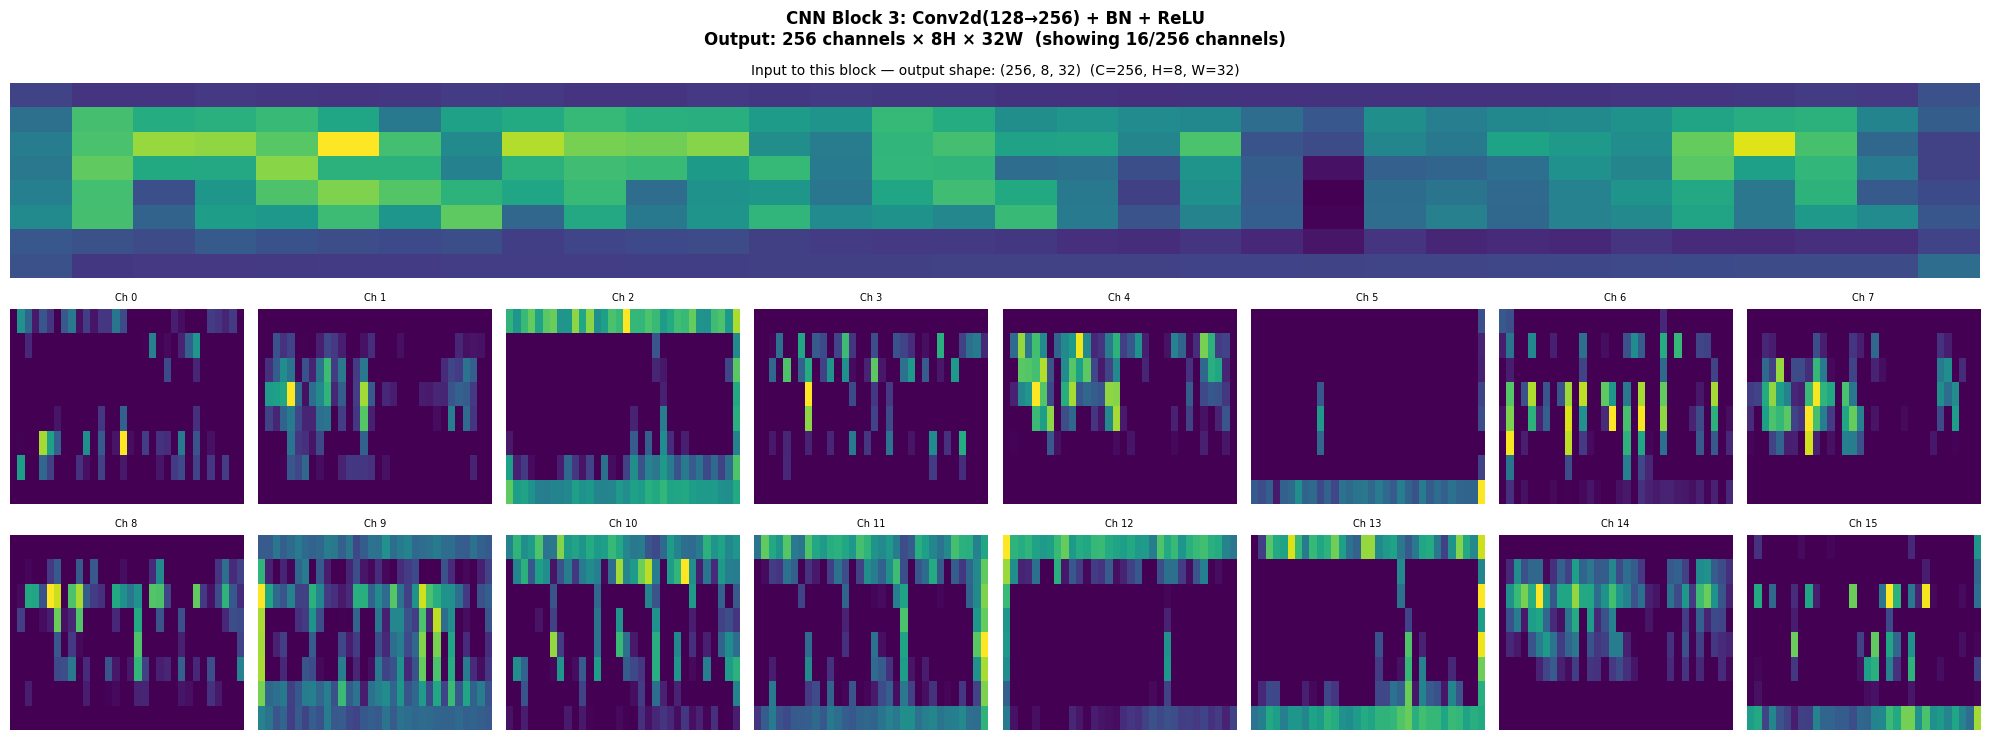

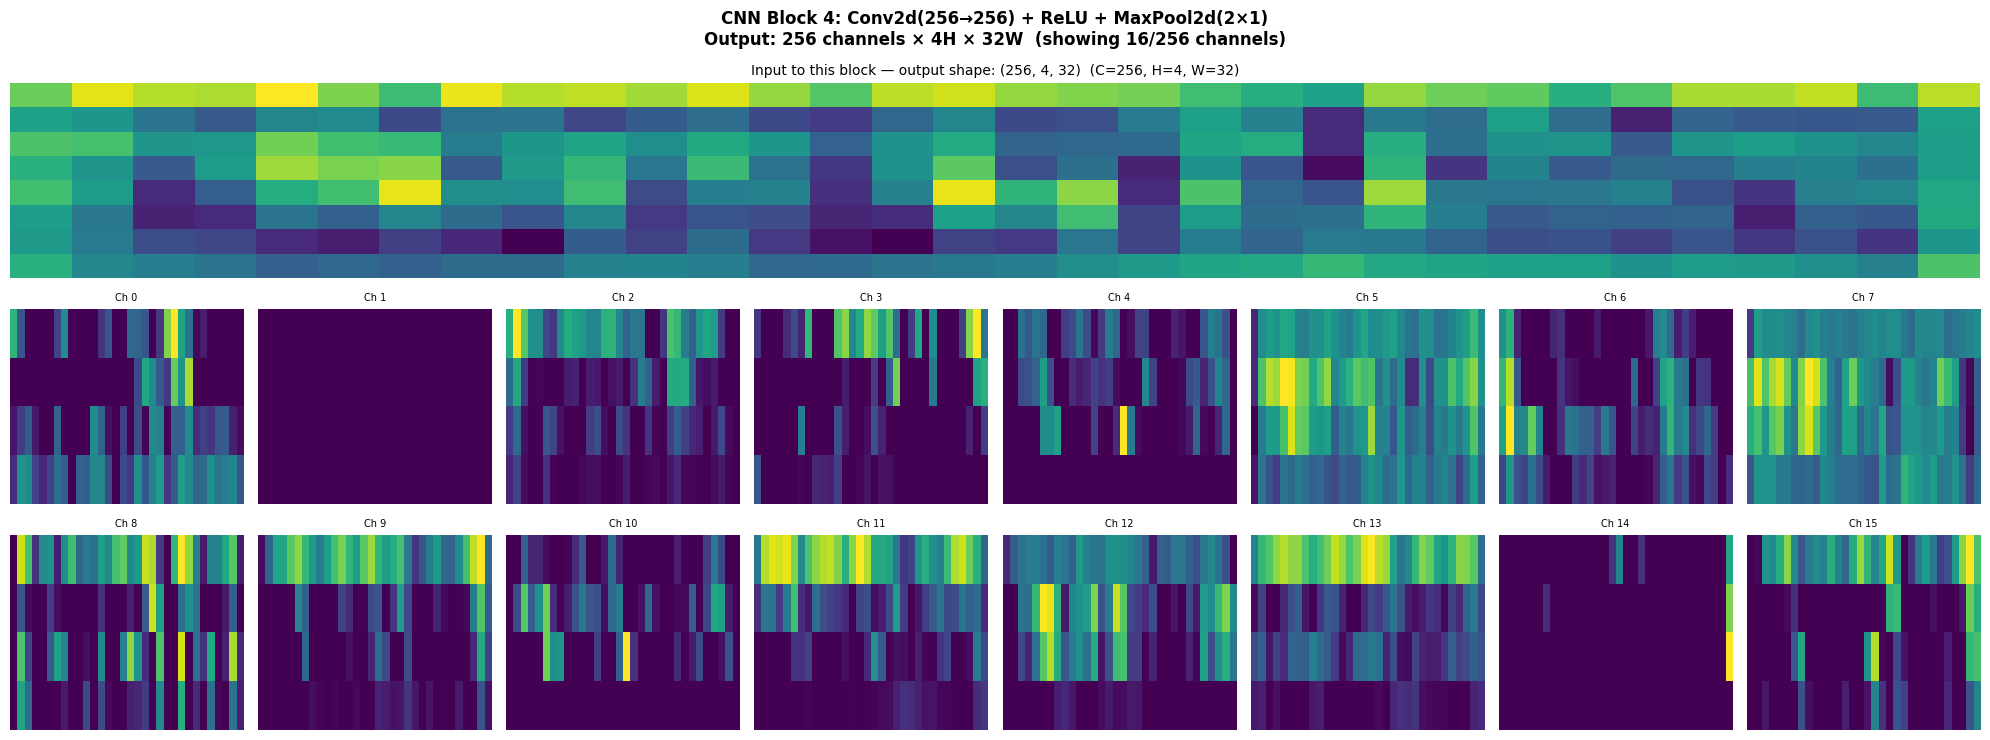

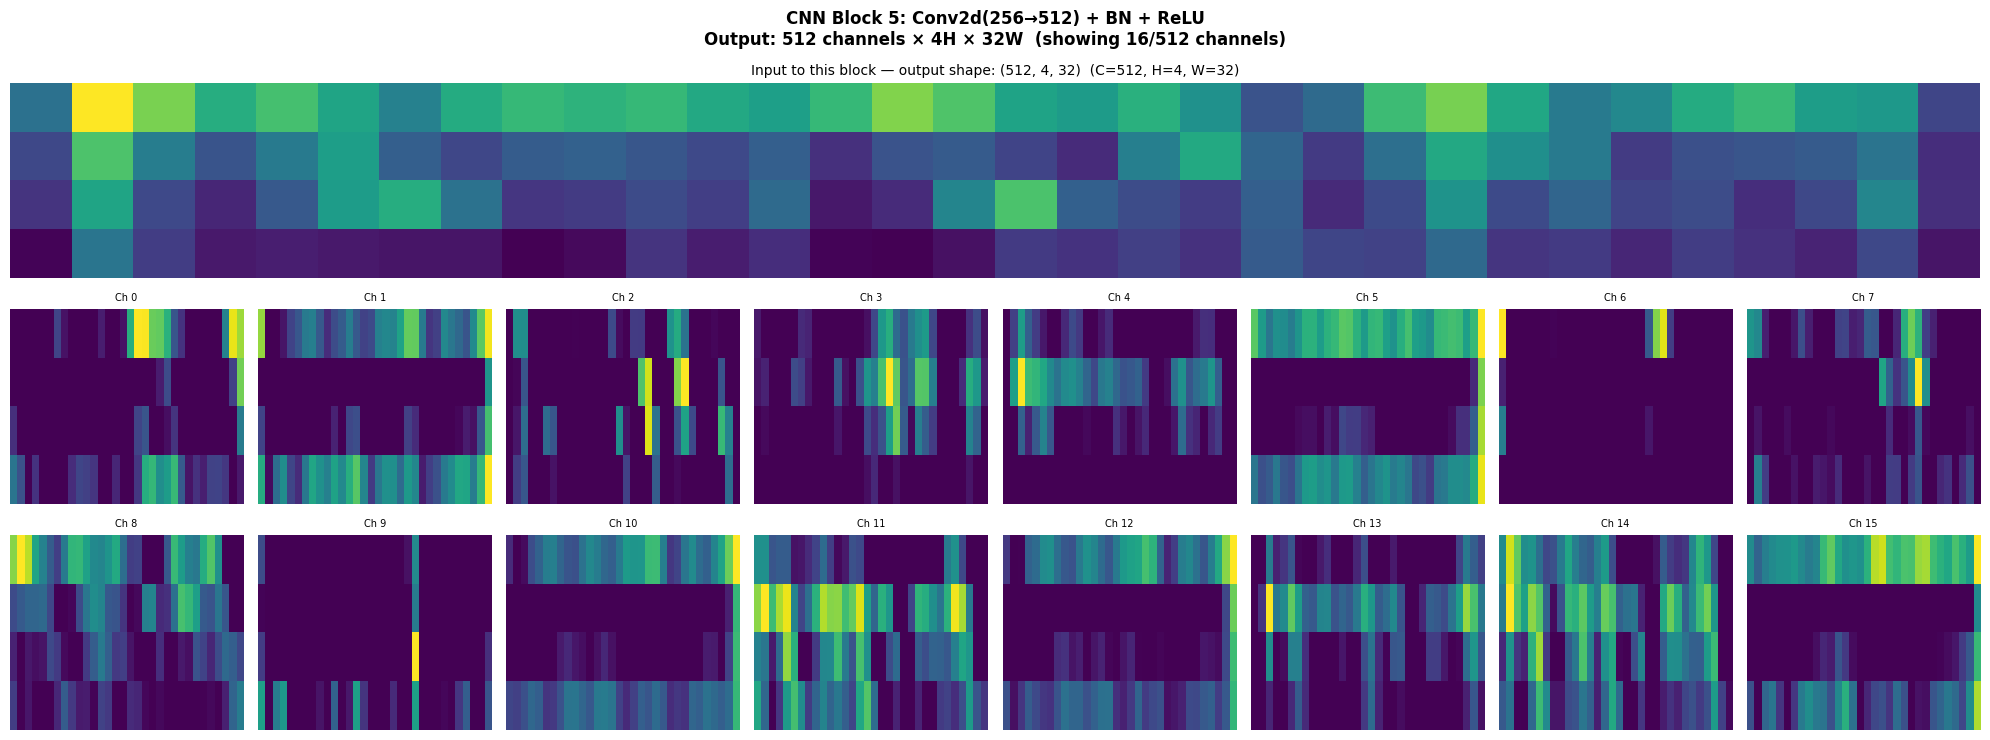

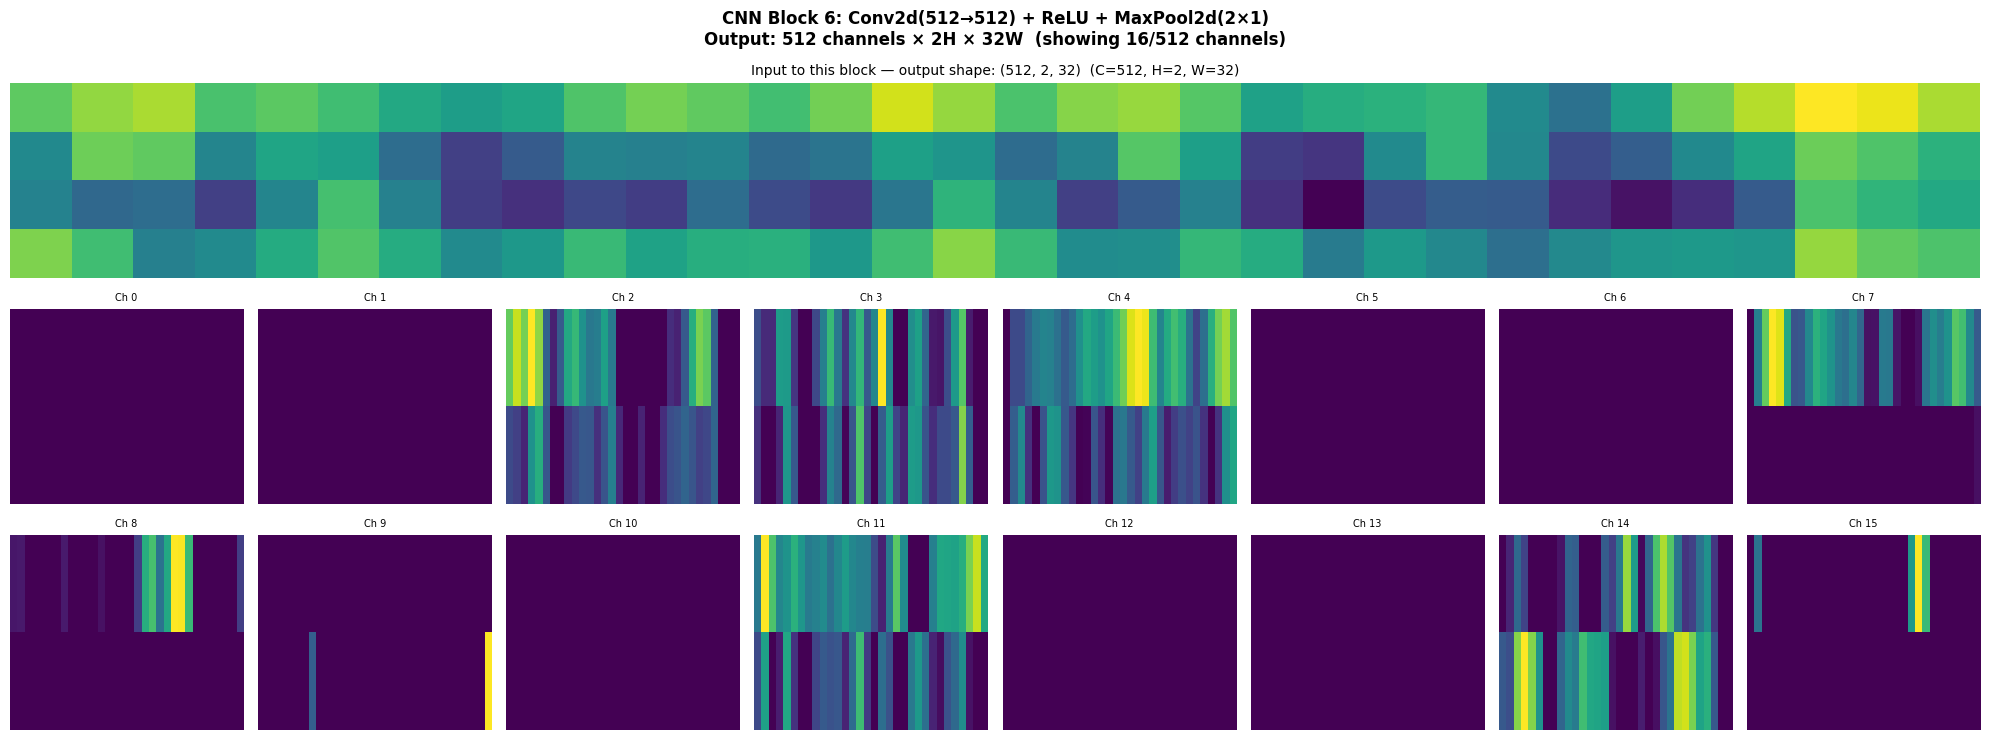

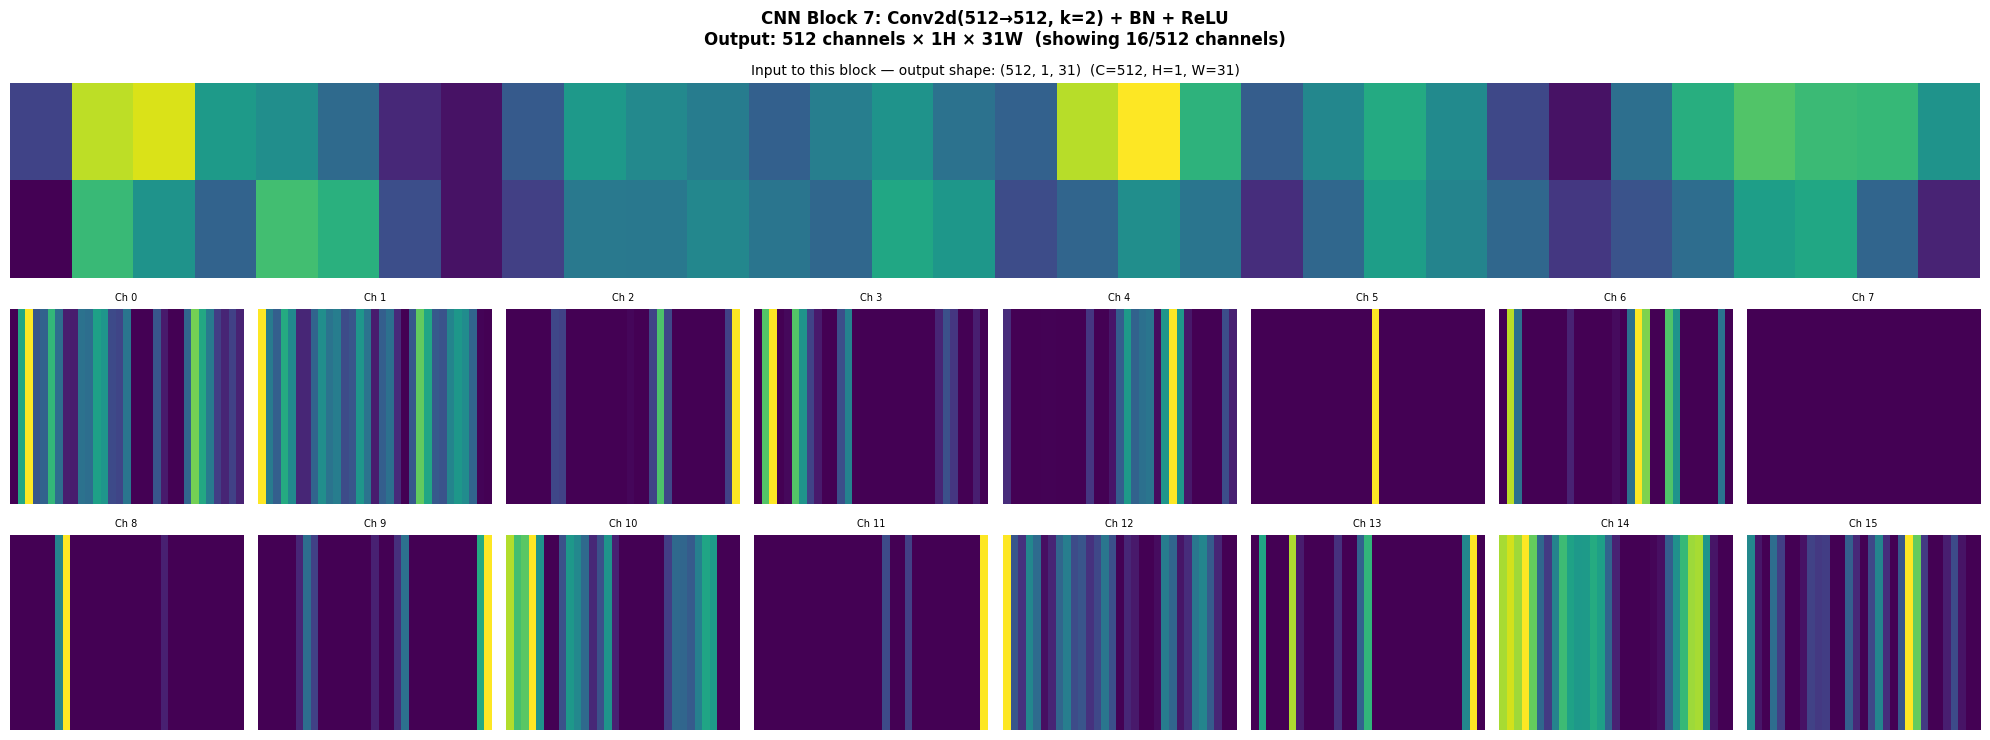

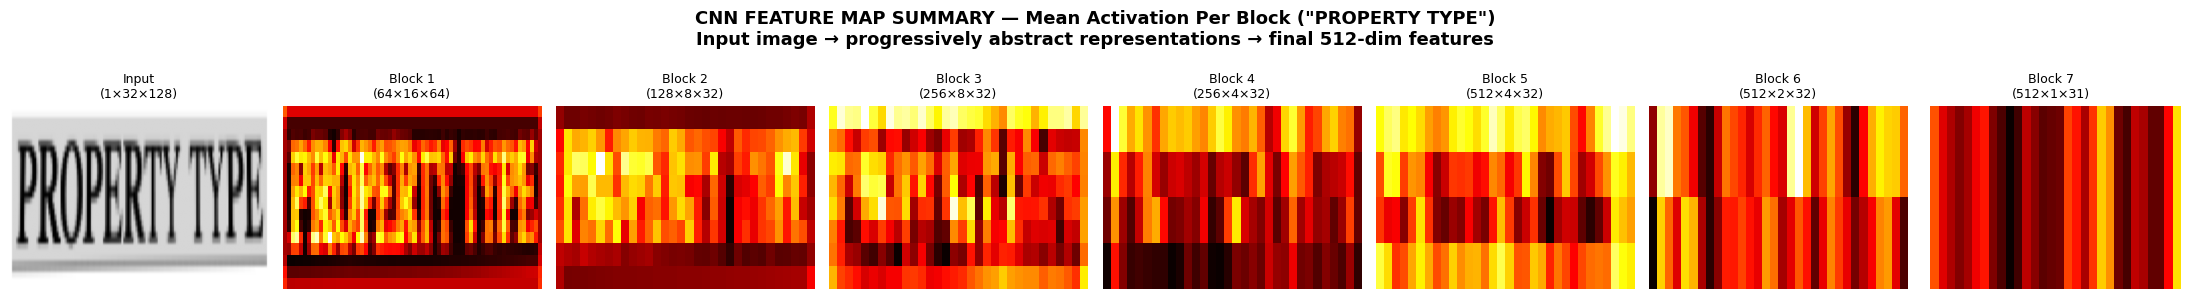


✓ Feature maps visualized for all 7 CNN blocks
  Early layers: detect edges, strokes, curves
  Middle layers: detect character parts, letter shapes
  Deep layers: detect full characters, word-level patterns


In [17]:

print(f"{'='*60}")
print(f"CNN FEATURE MAP VISUALIZATION")
print(f"{'='*60}")

# Pick a sample word to visualize
VIS_IDX = 0  # Change this to visualize a different word
vis_sample = dataset[VIS_IDX]
vis_word_img = all_words[VIS_IDX]['image']
vis_text = all_words[VIS_IDX]['text']
vis_tensor = vis_sample['image'].unsqueeze(0).to(device)  # (1, 1, 32, 128)

print(f"  Visualizing feature maps for: \"{vis_text}\"")
print(f"  Input tensor: {vis_tensor.shape}")
print(f"{'='*60}\n")

# Show the original word
fig, ax = plt.subplots(1, 1, figsize=(8, 2))
ax.imshow(vis_word_img)
ax.set_title(f'Input Word: "{vis_text}"', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# Define CNN blocks
cnn_block_info = [
    {'name': 'Block 1: Conv2d(1→64) + ReLU + MaxPool2d(2×2)',
     'layers': slice(0, 3), 'channels': 64},
    {'name': 'Block 2: Conv2d(64→128) + ReLU + MaxPool2d(2×2)',
     'layers': slice(3, 6), 'channels': 128},
    {'name': 'Block 3: Conv2d(128→256) + BN + ReLU',
     'layers': slice(6, 9), 'channels': 256},
    {'name': 'Block 4: Conv2d(256→256) + ReLU + MaxPool2d(2×1)',
     'layers': slice(9, 12), 'channels': 256},
    {'name': 'Block 5: Conv2d(256→512) + BN + ReLU',
     'layers': slice(12, 15), 'channels': 512},
    {'name': 'Block 6: Conv2d(512→512) + ReLU + MaxPool2d(2×1)',
     'layers': slice(15, 18), 'channels': 512},
    {'name': 'Block 7: Conv2d(512→512, k=2) + BN + ReLU',
     'layers': slice(18, 21), 'channels': 512},
]

# Extract feature maps from each block
model.eval()
cnn_layers = list(model.cnn.children())
feature_maps = []

with torch.no_grad():
    x = vis_tensor
    for block in cnn_block_info:
        for layer in cnn_layers[block['layers']]:
            x = layer(x)
        feature_maps.append(x.cpu().squeeze(0).numpy())  # (C, H, W)

# Visualize each block's feature maps
N_SHOW_CHANNELS = 16  # Show up to 16 channels per block

# Get the normalized grayscale input for display
input_gray = vis_sample['image'].squeeze(0).numpy()  # (32, 128)

for block_idx, (block, fmap) in enumerate(zip(cnn_block_info, feature_maps)):
    n_channels = fmap.shape[0]
    n_show = min(N_SHOW_CHANNELS, n_channels)
    cols = 8
    rows = (n_show + cols - 1) // cols + 1  # +1 for input image row

    fig, axes = plt.subplots(rows, cols, figsize=(20, 2.5 * rows))
    axes_flat = axes.flatten()

    # Row 0: Show input spanning full width
    for j in range(cols):
        axes[0][j].axis('off')

    ax_input = fig.add_subplot(rows, 1, 1)
    if block_idx == 0:
        ax_input.imshow(input_gray, cmap='gray', aspect='auto')
    else:
        prev_mean = feature_maps[block_idx - 1].mean(axis=0)
        ax_input.imshow(prev_mean, cmap='viridis', aspect='auto')
    ax_input.set_title(f'Input to this block — output shape: {fmap.shape}  '
                       f'(C={fmap.shape[0]}, H={fmap.shape[1]}, W={fmap.shape[2]})',
                       fontsize=10)
    ax_input.axis('off')

    # Individual channel maps
    for ch in range(n_show):
        ax = axes_flat[cols + ch]
        channel_map = fmap[ch]
        ax.imshow(channel_map, cmap='viridis', aspect='auto')
        ax.set_title(f'Ch {ch}', fontsize=7)
        ax.axis('off')

    for j in range(cols + n_show, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(f'CNN {block["name"]}\n'
                 f'Output: {n_channels} channels × {fmap.shape[1]}H × {fmap.shape[2]}W  '
                 f'(showing {n_show}/{n_channels} channels)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Summary: Mean activation across all channels per block
fig, axes = plt.subplots(1, len(feature_maps) + 1, figsize=(22, 3))

axes[0].imshow(input_gray, cmap='gray', aspect='auto')
axes[0].set_title(f'Input\n(1×{IMG_HEIGHT}×{IMG_WIDTH})', fontsize=9)
axes[0].axis('off')

for i, (block, fmap) in enumerate(zip(cnn_block_info, feature_maps)):
    mean_map = fmap.mean(axis=0)
    axes[i + 1].imshow(mean_map, cmap='hot', aspect='auto')
    axes[i + 1].set_title(f'Block {i+1}\n({fmap.shape[0]}×{fmap.shape[1]}×{fmap.shape[2]})',
                          fontsize=9)
    axes[i + 1].axis('off')

plt.suptitle(f'CNN FEATURE MAP SUMMARY — Mean Activation Per Block ("{vis_text}")\n'
             f'Input image → progressively abstract representations → final 512-dim features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Feature maps visualized for all 7 CNN blocks")
print(f"  Early layers: detect edges, strokes, curves")
print(f"  Middle layers: detect character parts, letter shapes")
print(f"  Deep layers: detect full characters, word-level patterns")
